<a href="https://colab.research.google.com/github/asifurrhamanjunayed-rgb/ML-Project/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  



```
# This is formatted as code
```
## Answer: This diabetes data is a classification problem which contains 9 collumns and 768 rows.This dataset provides medical diagonistic measurement on several health factors. The Outcome variable indicates whether the patient has diabetes (1) or not (0).



# 1. Dataset description

### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
import pandas as pd
df = pd.read_csv("diabetes_dataset.csv")
df.shape
df.describe()
df.info()
df.nunique()
df.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


##Answer:
**1.Features:** There are 9 features   
**2.Problem:** This is a binary classification where the paitent has diabetes or not  
**3.Data points:** 768 rows  
**4.Null values:** There are no null values in this dataset      
**5.Featues type:** 'Glucose'	'BloodPressure'	'SkinThickness'	'Insulin'	'BMI'	'DiabetesPedigreeFunction'	'Age' are numericalcollumn and 'Pregnancies','Outcome' are catagorical collumn.   
**6.Encoding:** Pregnencies collumn which is a catagorical collumn. This collumn means Number of times the patient has been pregnant. So there could be outliers.Therefore no need to encoding.  
**7.Correlation:**  There is highly correlation between Glucose and outcome.There is also a strong positive correlationbetween age and pregnancies     
**8.EDA:** The scatterplot shows the people with the higher glucose and BMI has more likely to have diabetes




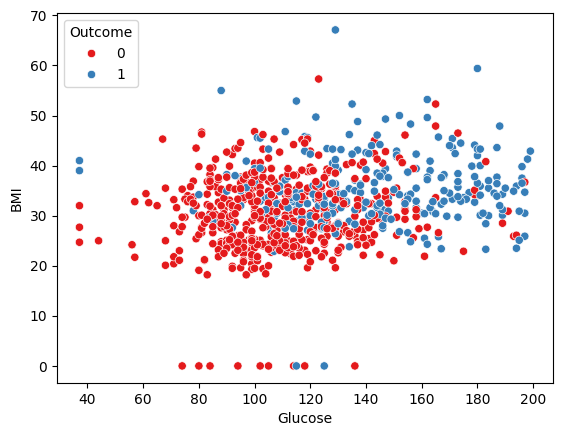

In [ ]:
from pandas.core import groupby
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=df["Glucose"], y=df["BMI"], hue=df["Outcome"], palette="Set1")
plt.show()



#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:

Here firstly i can see there is no null value but there are some outliers in some features. Glucose and Insulin collumn have more skewed kdeplot. So i applied IQR to remove outliers.
   

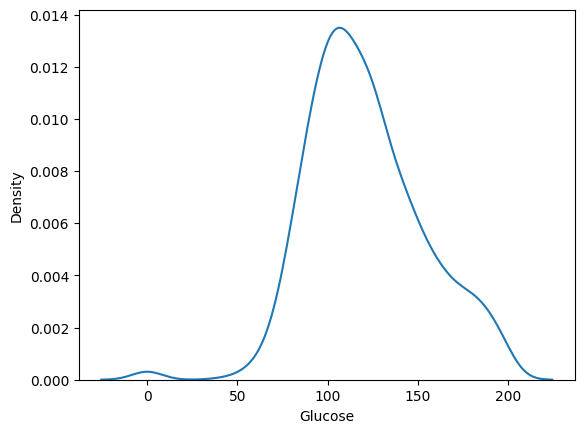

In [ ]:
df.nunique()
df.isnull().sum()
sns.kdeplot(data=df,x='Glucose')

glucose_Q1 = df['Glucose'].quantile(0.25)
glucose_Q3 = df['Glucose'].quantile(0.75)
glucose_IQR = glucose_Q3 - glucose_Q1
glucose_minimum = max(0,glucose_Q1 - 1.5 * glucose_IQR)
glucose_maximum = glucose_Q3 + 1.5 * glucose_IQR

df['Glucose']= df['Glucose'].clip(glucose_minimum , glucose_maximum)



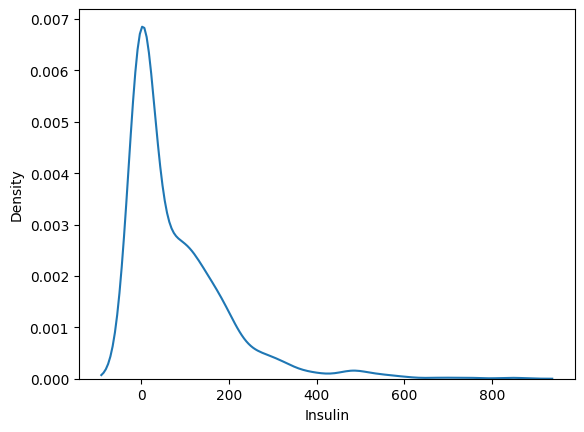

In [ ]:
sns.kdeplot(data=df,x='Insulin')

insulin_Q1 = df['Insulin'].quantile(0.25)
insulin_Q3 = df['Insulin'].quantile(0.75)
insulin_IQR = insulin_Q3 - insulin_Q1
insulin_minimum = max(0,insulin_Q1 - 1.5 * insulin_IQR)
insulin_maximum = insulin_Q3 + 1.5 * insulin_IQR

df['Insulin']= df['Insulin'].clip(insulin_minimum , insulin_maximum)

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:
Here i choose all the features for my model because i think they have importance to predict the outcome.And i also split the data into train and test section where 20 percents of data are taken for testing the model.


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome',axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pipeline = Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',pipeline,['Age','BMI','DiabetesPedigreeFunction','Glucose','Insulin','Pregnancies','SkinThickness'])


    ],
    remainder='drop'
)


knn_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',KNeighborsClassifier(n_neighbors=30,metric='minkowski',p=2))
    ]
)

SVC_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',SVC())
    ]
)




# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
knn_model.fit(X_train,y_train)
SVC_model.fit(X_train,y_train)

SVC_pred = SVC_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

print('SVC Accuracy:',accuracy_score(y_test,SVC_pred))
print('KNN Accuracy:',accuracy_score(y_test,knn_pred))

SVC Accuracy: 0.7272727272727273
KNN Accuracy: 0.7792207792207793


#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

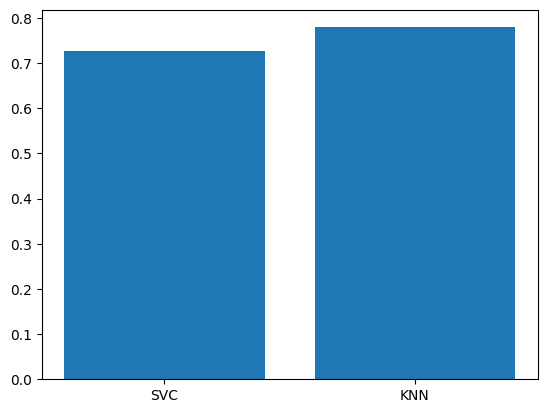

In [ ]:
plt.bar(['SVC','KNN'],[accuracy_score(y_test,SVC_pred),accuracy_score(y_test,knn_pred)])
plt.show()

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
print('SVC Precision:',precision_score(y_test,SVC_pred))
print('KNN Precision:',precision_score(y_test,knn_pred))
print('SVC Confusion Matrix:\n',confusion_matrix(y_test,SVC_pred))
print('KNN Confusion Matrix:\n',confusion_matrix(y_test,knn_pred))

SVC Precision: 0.6274509803921569
KNN Precision: 0.7560975609756098
SVC Confusion Matrix:
 [[80 19]
 [23 32]]
KNN Confusion Matrix:
 [[89 10]
 [24 31]]


Here for this data set i think KNN fits better. Because it has better acuracy score and over all true and false prediction.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

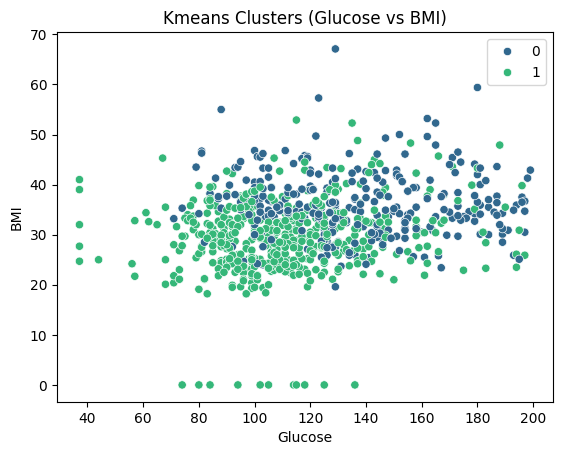

In [ ]:
from sklearn.cluster import KMeans

X = df.drop('Outcome',axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    max_iter=500,
    random_state=42
)
kmeans.fit(X_scaled)
label_kmeans = kmeans.labels_

sns.scatterplot(x=df["Glucose"], y=df["BMI"], hue=label_kmeans, palette="viridis")
plt.title("Kmeans Clusters (Glucose vs BMI)")
plt.show()

In supervised model, model can fit with training data and for 8 collumns there are lots of weights and biased that's why it performed well but in unsupervised the Kmeans algorithm split the data into two different parts. I think supervised model performed well in this data set

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:
For me the first two algorithm which are linear and logistic regression were tough because it was built from scratch. Then day by day when we get introduced to the new models it was very informative and we also got to know when and how to use those models.
The easiest topic was those unsuppervised model because it was easy to implement and easy to understand. Although we got to know many this in this course i hope we can use those and make a better research paper